# Data Preprocessing Tools

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Importing the dataset

In [ ]:
dataset = pd.read_csv('heart.csv')
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Analyze Dataset


In [ ]:
dataset.shape

(1025, 14)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
dataset.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
dup_rec=dataset[dataset.duplicated()]
print (dup_rec)
dataset=dataset.drop_duplicates()

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
15     34    0   1       118   210    0        1      192      0      0.7   
31     50    0   1       120   244    0        1      162      0      1.1   
43     46    1   0       120   249    0        0      144      0      0.8   
55     55    1   0       140   217    0        1      111      1      5.6   
61     66    0   2       146   278    0        0      152      0      0.0   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
15        2   0     2       1  
31        2

In [ ]:
dataset.shape

(302, 14)

In [ ]:
df=pd.DataFrame(dataset)

Check Correlation of independent variables with "Target"

In [ ]:
print(df.corr()["target"].abs().sort_values(ascending=False))

target      1.000000
exang       0.435601
cp          0.432080
oldpeak     0.429146
thalach     0.419955
ca          0.408992
slope       0.343940
thal        0.343101
sex         0.283609
age         0.221476
trestbps    0.146269
restecg     0.134874
chol        0.081437
fbs         0.026826
Name: target, dtype: float64


Visualizing Data

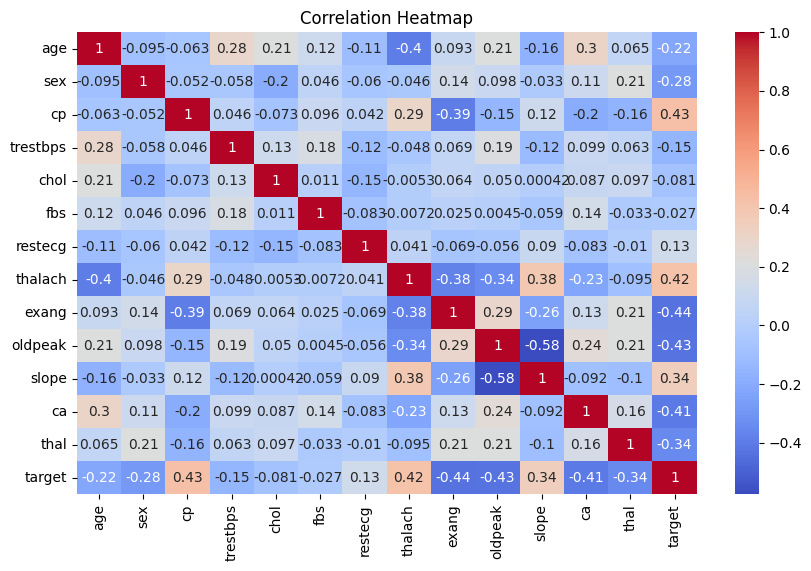

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Splitting Dependant and Independant variables

In [ ]:
x=df.loc[:,df.columns!='target']
#print(x)
y = df['target']
#print(y.count())
val, count = np.unique(y, return_counts=True)
#print(val)
#print(count)
print("Patients with No Heart Disease "+str(count[0]))
print("Patients with Heart Disease "+str(count[1]))

Patients with No Heart Disease 138
Patients with Heart Disease 164


<Axes: xlabel='target', ylabel='count'>

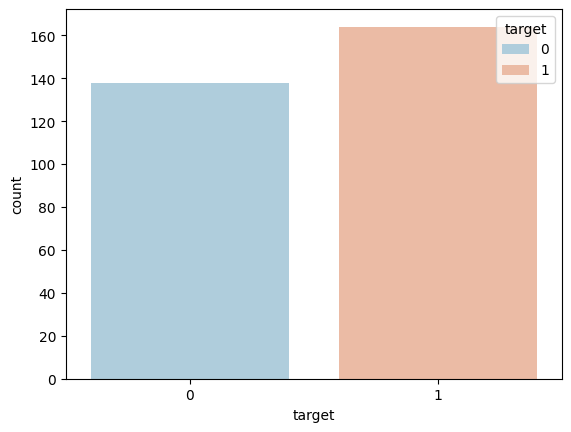

In [ ]:
sns.countplot(x='target',data=df,hue="target",palette="RdBu_r")

Count of patients by gender in the dataset

In [ ]:
val_s, count_s = np.unique(x['sex'], return_counts=True)
print("Male Patients "+str(count_s[1]))
print("Female Patients "+str(count_s[0]))

Male Patients 206
Female Patients 96


target    0   1
sex            
0        24  72
1       114  92
target         0         1
sex                       
0       0.250000  0.750000
1       0.553398  0.446602


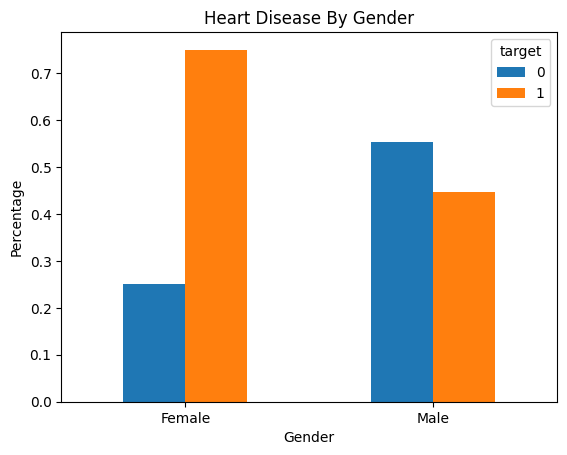

In [ ]:
gdr_hds=pd.crosstab(x.sex,y)
print(gdr_hds)
gdr_hds=pd.crosstab(x.sex,y,normalize='index')
print(gdr_hds)
gdr_hds.plot(kind="bar", stacked=False,rot=0)
plt.xticks([0,1], ['Female', 'Male'])
plt.title('Heart Disease By Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.show()

Heart Disease by Fasting Blood Sugar

In [ ]:
pd.crosstab(df.fbs,df.target).plot(kind="bar",figsize=(20,10),color=['#4286f4','#49242'])
plt.title('Heart Disease Frequency According To FBS')
plt.xlabel('FBS - (Fasting Blood Sugar > 120 mg/dl)(1=True, 0=False)')
plt.xticks(rotation=0)
plt.legend(["Do Not Have Disease", "Have Disease"])
plt.ylabel('FBS')
plt.show()

NameError: name 'pd' is not defined

## Splitting the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
x_train_cat = x_train[['sex','cp','fbs','restecg','exang','slope','ca','thal']]
x_train_non_cat = x_train[['age','trestbps','chol','thalach','oldpeak']]
x_test_cat = x_test[['sex','cp','fbs','restecg','exang','slope','ca','thal']]
x_test_non_cat = x_test[['age','trestbps','chol','thalach','oldpeak']]

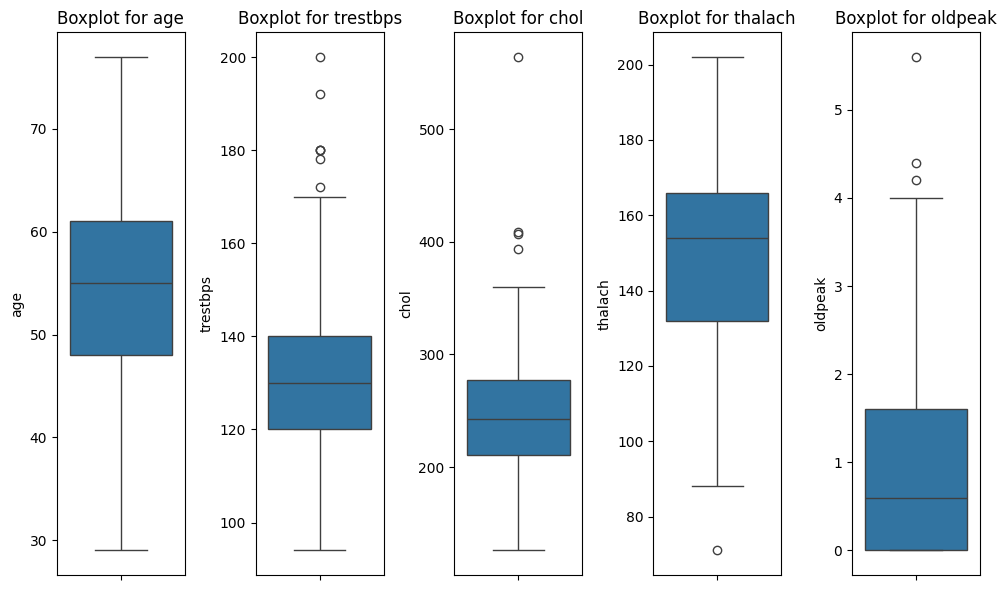

In [ ]:
import seaborn as sns
disp_cols = x_train_non_cat.columns
plt.figure(figsize=(10, 6))
for i in range(len(disp_cols)):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=disp_cols[i], data=x_train_non_cat)
    plt.title("Boxplot for "+disp_cols[i])
plt.tight_layout()
plt.show()

## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler,RobustScaler
#sc = StandardScaler()
sc = RobustScaler()
x_train_scaled = sc.fit_transform(x_train_non_cat)
x_test_scaled = sc.transform(x_test_non_cat)

In [ ]:
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train_non_cat.columns, index=x_train_non_cat.index)
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x_test_non_cat.columns, index=x_test_non_cat.index)
print(x_train_scaled_df)


          age  trestbps      chol   thalach  oldpeak
163 -0.538462      -0.3  0.469697  0.352941  -0.0625
291  0.230769      -0.1  0.242424 -0.705882   1.5000
280 -0.769231       0.0 -0.136364  0.617647   0.0000
85  -0.846154      -0.5 -0.348485  0.470588  -0.3750
239  0.538462       1.0  0.015152  0.000000   0.5000
..        ...       ...       ...       ...      ...
267  0.923077      -0.5 -0.090909 -2.441176   0.2500
77   0.615385       0.5 -0.848485 -0.294118   2.1250
125  0.384615       1.0 -0.045455  0.500000   0.1875
522  0.923077       1.1  0.515152  0.529412  -0.3750
119 -1.000000      -0.5  0.787879  0.235294  -0.3750

[241 rows x 5 columns]


In [ ]:
x_train = pd.concat([x_train_scaled_df, x_train_cat], axis=1)
x_test = pd.concat([x_test_scaled_df, x_test_cat], axis=1)
print(x_train)
print(x_test)
print(y_train)
print(y_test)

          age  trestbps      chol   thalach  oldpeak  sex  cp  fbs  restecg  \
163 -0.538462      -0.3  0.469697  0.352941  -0.0625    1   0    0        0   
291  0.230769      -0.1  0.242424 -0.705882   1.5000    1   0    0        0   
280 -0.769231       0.0 -0.136364  0.617647   0.0000    0   1    0        0   
85  -0.846154      -0.5 -0.348485  0.470588  -0.3750    1   1    0        1   
239  0.538462       1.0  0.015152  0.000000   0.5000    0   0    0        1   
..        ...       ...       ...       ...      ...  ...  ..  ...      ...   
267  0.923077      -0.5 -0.090909 -2.441176   0.2500    1   0    0        1   
77   0.615385       0.5 -0.848485 -0.294118   2.1250    1   0    0        0   
125  0.384615       1.0 -0.045455  0.500000   0.1875    0   3    0        1   
522  0.923077       1.1  0.515152  0.529412  -0.3750    0   2    0        1   
119 -1.000000      -0.5  0.787879  0.235294  -0.3750    1   1    0        1   

     exang  slope  ca  thal  
163      0      1   0

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
lr = LogisticRegression()
lr.fit(x_train, y_train)
lr_predict=lr.predict(x_test)
lr_cm=confusion_matrix(y_test,lr_predict)
lr_acc=accuracy_score(y_test,lr_predict)
print(lr_cm)
print(lr_acc)

[[22 10]
 [ 3 26]]
0.7868852459016393


Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)
nb_predict=nb.predict(x_test)
nb_cm=confusion_matrix(y_test,nb_predict)
nb_acc=accuracy_score(y_test,nb_predict)
print(nb_cm)
print(nb_acc)

[[27  5]
 [ 4 25]]
0.8524590163934426


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
dt_predict=dt.predict(x_test)
dt_cm=confusion_matrix(y_test,dt_predict)
dt_acc=accuracy_score(y_test,dt_predict)
print(dt_cm)
print(dt_acc)

[[24  8]
 [ 9 20]]
0.7213114754098361


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=30,random_state=12,max_depth=5)
rf.fit(x_train,y_train)
rf_predict=rf.predict(x_test)
rf_cm=confusion_matrix(y_test,rf_predict)
rf_acc=accuracy_score(y_test,rf_predict)
print(rf_cm)
print(rf_acc)


[[25  7]
 [ 3 26]]
0.8360655737704918


Support Vector Classifier

In [ ]:
from sklearn.svm import SVC
svc=SVC(kernel='rbf',C=5)
svc.fit(x_train,y_train)
svc_predict=svc.predict(x_test)
svc_cm=confusion_matrix(y_test,svc_predict)
svc_acc=accuracy_score(y_test,svc_predict)
print(svc_cm)
print(svc_acc)

[[27  5]
 [ 6 23]]
0.819672131147541


K-NN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
knn_predict=knn.predict(x_test)
knn_cm=confusion_matrix(y_test,knn_predict)
knn_acc=accuracy_score(y_test,knn_predict)
print(knn_cm)
print(knn_acc)

[[23  9]
 [ 4 25]]
0.7868852459016393


Accuracies

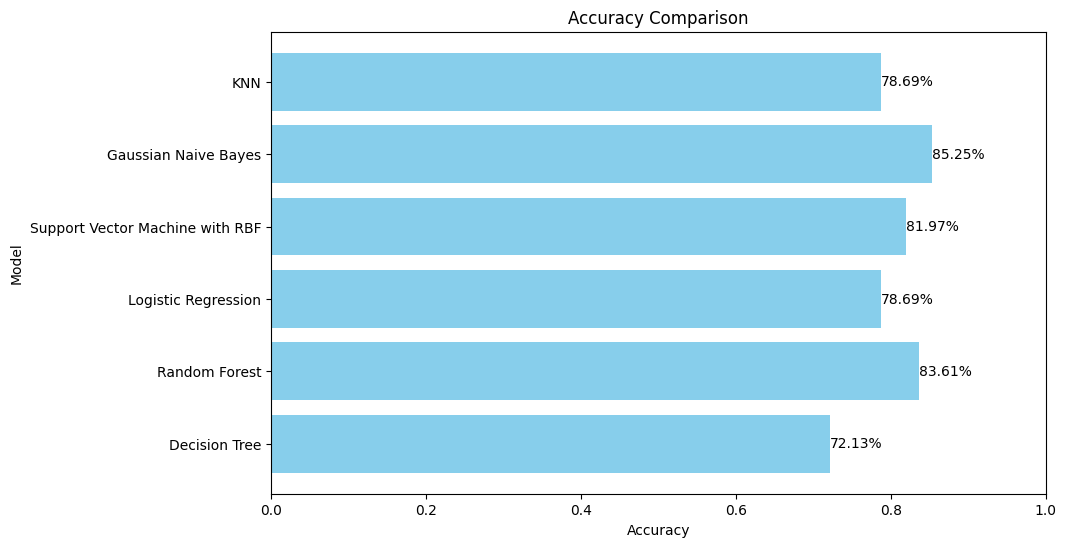

In [ ]:
classifiers = ['Decision Tree', 'Random Forest', 'Logistic Regression', 'Support Vector Machine with RBF', 'Gaussian Naive Bayes','KNN']
accuracies = [dt_acc,rf_acc,lr_acc,svc_acc,nb_acc,knn_acc]
plt.figure(figsize=(10, 6))
bars = plt.barh(classifiers, accuracies, color='skyblue')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Accuracy Comparison')
plt.xlim(0, 1)

# Percentage labels on each bar
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{accuracy*100:.2f}%',
             va='center', ha='left', fontsize=10, color='black')

plt.show()